In [9]:
import pandas as pd
import numpy as np
import cv2
import glob
import os
import matplotlib.pyplot as plt
from skimage import io
import json

In [10]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

In [11]:
def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

In [12]:
def get_defect_coordinates(json_data, image_number):
    """
    Parses JSON data to extract defect coordinates for a specific image number.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.
        image_number (str or int): The specific image number to look for in the JSON.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        value = item.get('signal', {}).get(str(image_number))
        
        if value is not None:
            for x_coord in item.get('x_coord', []):
                
                defect_dict[x_coord] = {
                    'start': item.get('y_start', []), 
                    'stop': item.get('y_stop', [])
                }

    return defect_dict

In [13]:
def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

In [14]:
def replace_defects(img, defects):
    """
    Replaces defective pixels in an image with 0 (black) based on provided coordinates.

    Args:
        img (numpy.ndarray): The original image array.
        defects (dict): A dictionary of defect coordinates generated by `get_defect_coordinates`.

    Returns:
        numpy.ndarray: A copy of the image with the defective pixels set to 0.
    """
    image_copy = img.copy()
    
    for x_coord, values in defects.items():
        for start_y, end_y in zip(values['start'], values['stop']):
            image_copy[start_y:end_y + 1, x_coord] = 0
            
    return image_copy

In [24]:
def analyser_et_corriger_image(image_path, json_path=None, show_images=True):
    """
    Fonction globale qui charge les documents, extrait les défauts, 
    corrige l'image et affiche les résultats.
    
    Args:
        image_path (str): Le chemin vers l'image.
        json_path (str, optional): Le chemin vers le fichier JSON. S'il n'est pas fourni, 
                                   il sera déduit à partir du chemin de l'image.
        show_images (bool): True pour afficher l'image originale et l'image corrigée.
        image_number (str/int): Le numéro de l'image à analyser dans le JSON (par défaut "0").
        
    Returns:
        dict: Un dictionnaire avec les x en index, associés à une liste de tuples (Ystart, Ystop).
    """

    nom_fichier = os.path.basename(image_path)
    chaine_numero = nom_fichier.split('_')[1].split('.')[0]
    image_number = int(chaine_numero)
    
    if json_path is None:
        dossier_image = os.path.dirname(image_path)
        fichiers_json = glob.glob(os.path.join(dossier_image, "*.json"))
        json_path = fichiers_json[0]

    raw_image = load_image(image_path)
    defect_data = load_json(json_path)
    
    raw_defects = get_defect_coordinates(defect_data, image_number)
    
    formatted_defects = {}
    for x_coord, values in raw_defects.items():
        formatted_defects[int(x_coord)] = list(zip(values['start'], values['stop']))
        
    normalized_img = normalize_to_8bit(raw_image)
    corrected_image = replace_defects(normalized_img, raw_defects)
    
    if show_images:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(normalized_img, cmap='gray')
        axes[0].set_title("Image Originale (Normalisée)")
        axes[0].axis('off')
        
        axes[1].imshow(corrected_image, cmap='gray')
        axes[1].set_title("Image avec les erreurs superposées")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    return formatted_defects

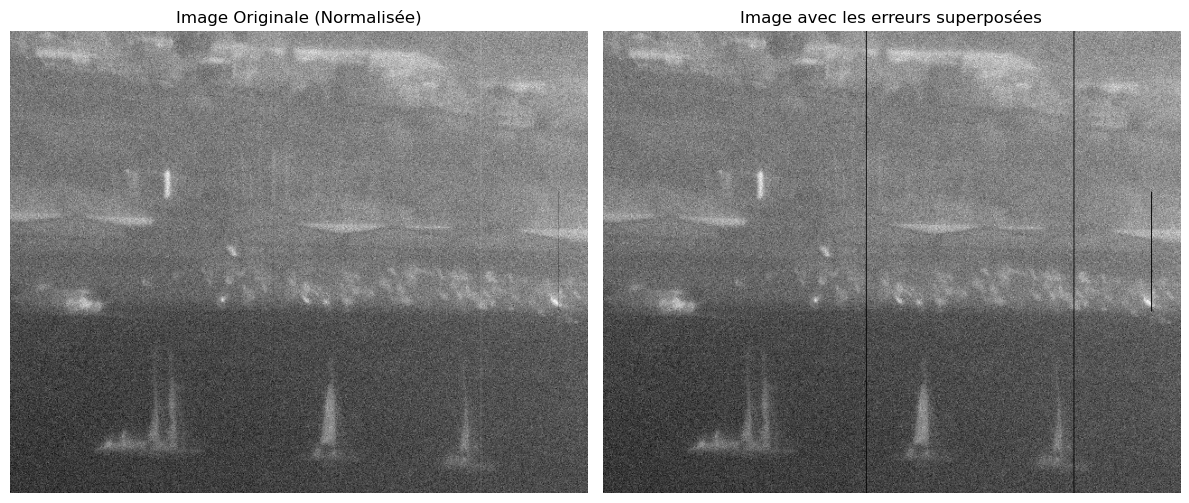

{291: [(0, 512)], 521: [(0, 512)], 607: [(178, 310)]}


In [26]:
resultats = analyser_et_corriger_image(
    image_path=r"C:\Users\eliot\Desktop\Obsidian Vault\03. Cours\S2\Data_Challenge\train\VGA\sequence_3\low dyn with columns 3\frame_0497.png",
    show_images=True
)
print(resultats)